<a href="https://colab.research.google.com/github/estebancardonad/Trabajos_Python_xd/blob/main/Reto%20S10%20y%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Felicidades, has terminado el Curso de Introducción a Python**

Para ello vamos a hacer un pequeño desafio que nos permita poner en practica todo lo que hemos aprendido a lo largo de este curso.

Empecemos creando nuestra base de datos usando Yahoo Finance

1. descarga 6 activos difrentes con los valores del ultimo año (entre ellos elige una criptomoneda y el dolar en pesos (COP=X), con una periodicidad díaria, y elije el valor del cierre (Close) y el volumen (Volume) de los movimientos, verifica los datos y limpia si es necesario con la estrategia de valores vecinos.

2. Crea una nueva variable categorica llamada "catvolume#NombreActivo", en función de uno de los activos y sus valores de volumen de venta, en donde dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio" al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

3. Crea una columna adicional que se llame index y ponla en la primera columna de datos

4. Crea una columna de la criptomoneda en valores pesos multiplicandola por el valor del dolar en cada día.

5. Crea un resumen estadistico de las variables y analizar

6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma,  diagrama de cajas y bigotes y diagrama circular (Variable categorica)

7. Realice una matriz de correlación para las variables originales

8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

In [2]:
#Importación y limpeza de datos
import yfinance as yf
tickers="EC","GOOG", "KO", "PEP", "DPZ","BTC-USD", "COP=X"
data=yf.download(tickers=tickers,period="1y", interval="1d",
                 auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()

[*********************100%***********************]  7 of 7 completed
/tmp/ipython-input-632670069.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()


In [3]:
#Visualización de los datos
data.head()

Price               Close                                                 \
Ticker            BTC-USD        COP=X         DPZ        EC        GOOG   
Date                                                                       
2024-12-05   96593.570312  4425.750000  458.461304  7.245496  173.550430   
2024-12-06   99920.710938  4413.669922  452.728210  7.092104  175.720917   
2024-12-07   99923.335938  4376.152344  450.905823  7.407911  176.528305   
2024-12-08  101236.015625  4376.152344  450.905823  7.407911  176.528305   
2024-12-09   97432.718750  4376.152344  450.905823  7.407911  176.528305   

Price                                    Volume                             \
Ticker             KO         PEP       BTC-USD COP=X       DPZ         EC   
Date                                                                         
2024-12-05  61.116852  154.516800  1.492189e+11   0.0  466200.0  1803900.0   
2024-12-06  60.738029  153.210815  9.453477e+10   0.0  387200.0  2430300.0   
2024-12-07  60.806023  154.842056  4.417751e+10   0.0  504900.0  3721300.0   
2024-12-08  60.806023  154.842056  4.412575e+10   0.0  504900.0  3721300.0   
2024-12-09  60.806023  154.842056  1.106765e+11   0.0  504900.0  3721300.0   

Price                                          
Ticker            GOOG          KO        PEP  
Date                                           
2024-12-05  16145500.0  21040400.0  5229600.0  
2024-12-06  13319500.0  15581100.0  8359200.0  
2024-12-07  19887800.0  22348300.0  8380400.0  
2024-12-08  19887800.0  22348300.0  8380400.0  
2024-12-09  19887800.0  22348300.0  8380400.0

In [4]:
len(data)

365

In [5]:
data.isnull().sum()

Price   Ticker 
Close   BTC-USD    0
        COP=X      0
        DPZ        0
        EC         0
        GOOG       0
        KO         0
        PEP        0
Volume  BTC-USD    0
        COP=X      0
        DPZ        0
        EC         0
        GOOG       0
        KO         0
        PEP        0
dtype: int64

In [6]:
##2. Crea una nueva variable categorica llamada "catvolume#NombreActivo",
#en función de uno de los activos y sus valores de volumen de venta, en donde
#dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio"
#al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

import pandas as pd
#Crear la nueva variable

volume_CocaCola = data['Volume']['KO']

# Calcular cuartiles y crear la columna
labels = ['bajo', 'medio', 'alto', 'muy_alto']
data['Volume', 'catvolumeKO'] = pd.qcut(volume_CocaCola, q=4, labels=labels, duplicates='drop')



In [7]:
#Validar nueva columna Catvolumexxxx
data

Price               Close                                                  \
Ticker            BTC-USD        COP=X         DPZ         EC        GOOG   
Date                                                                        
2024-12-05   96593.570312  4425.750000  458.461304   7.245496  173.550430   
2024-12-06   99920.710938  4413.669922  452.728210   7.092104  175.720917   
2024-12-07   99923.335938  4376.152344  450.905823   7.407911  176.528305   
2024-12-08  101236.015625  4376.152344  450.905823   7.407911  176.528305   
2024-12-09   97432.718750  4376.152344  450.905823   7.407911  176.528305   
...                   ...          ...         ...        ...         ...   
2025-11-30   90394.312500  3691.856689  423.850006   9.950000  315.119995   
2025-12-01   86321.570312  3691.856689  423.850006   9.950000  315.119995   
2025-12-02   91350.203125  3808.399902  424.640015   9.910000  316.019989   
2025-12-03   93527.804688  3816.250000  431.690002  10.130000  320.619995   
2025-12-04   92567.500000  3768.149902  427.070007  10.060000  318.390015   

Price                                    Volume                             \
Ticker             KO         PEP       BTC-USD COP=X       DPZ         EC   
Date                                                                         
2024-12-05  61.116852  154.516800  1.492189e+11   0.0  466200.0  1803900.0   
2024-12-06  60.738029  153.210815  9.453477e+10   0.0  387200.0  2430300.0   
2024-12-07  60.806023  154.842056  4.417751e+10   0.0  504900.0  3721300.0   
2024-12-08  60.806023  154.842056  4.412575e+10   0.0  504900.0  3721300.0   
2024-12-09  60.806023  154.842056  1.106765e+11   0.0  504900.0  3721300.0   
...               ...         ...           ...   ...       ...        ...   
2025-11-30  71.949997  149.509995  3.849790e+10   0.0  634700.0  1872800.0   
2025-12-01  71.949997  149.509995  8.796289e+10   0.0  634700.0  1872800.0   
2025-12-02  70.669998  148.610001  7.854680e+10   0.0  645000.0  1593100.0   
2025-12-03  70.809998  148.059998  7.765020e+10   0.0  483900.0  1354500.0   
2025-12-04  70.449997  146.910004  6.129335e+10   0.0  570800.0  1104300.0   

Price                                                      
Ticker            GOOG          KO        PEP catvolumeKO  
Date                                                       
2024-12-05  16145500.0  21040400.0  5229600.0    muy_alto  
2024-12-06  13319500.0  15581100.0  8359200.0        alto  
2024-12-07  19887800.0  22348300.0  8380400.0    muy_alto  
2024-12-08  19887800.0  22348300.0  8380400.0    muy_alto  
2024-12-09  19887800.0  22348300.0  8380400.0    muy_alto  
...                ...         ...        ...         ...  
2025-11-30  28520600.0  14388100.0  7623300.0       medio  
2025-12-01  28520600.0  14388100.0  7623300.0       medio  
2025-12-02  24668200.0  19871300.0  6830300.0    muy_alto  
2025-12-03  32285100.0  17001700.0  5109200.0        alto  
2025-12-04  20803900.0  17704700.0  6802100.0        alto  

[365 rows x 15 columns]

In [9]:
#Contar cantidad de valores por categoria
print(data['Volume', 'catvolumeKO'].value_counts())

(Volume, catvolumeKO)
bajo        92
medio       91
alto        91
muy_alto    91
Name: count, dtype: int64


In [10]:
## NUeva Columna llamada Index
Index = range(1, len(data) + 1)

print(Index)

data.insert(0, 'Index', Index)


range(1, 366)


In [11]:
data

Price      Index          Close                                      \
Ticker                  BTC-USD        COP=X         DPZ         EC   
Date                                                                  
2024-12-05     1   96593.570312  4425.750000  458.461304   7.245496   
2024-12-06     2   99920.710938  4413.669922  452.728210   7.092104   
2024-12-07     3   99923.335938  4376.152344  450.905823   7.407911   
2024-12-08     4  101236.015625  4376.152344  450.905823   7.407911   
2024-12-09     5   97432.718750  4376.152344  450.905823   7.407911   
...          ...            ...          ...         ...        ...   
2025-11-30   361   90394.312500  3691.856689  423.850006   9.950000   
2025-12-01   362   86321.570312  3691.856689  423.850006   9.950000   
2025-12-02   363   91350.203125  3808.399902  424.640015   9.910000   
2025-12-03   364   93527.804688  3816.250000  431.690002  10.130000   
2025-12-04   365   92567.500000  3768.149902  427.070007  10.060000   

Price                                                Volume                  \
Ticker            GOOG         KO         PEP       BTC-USD COP=X       DPZ   
Date                                                                          
2024-12-05  173.550430  61.116852  154.516800  1.492189e+11   0.0  466200.0   
2024-12-06  175.720917  60.738029  153.210815  9.453477e+10   0.0  387200.0   
2024-12-07  176.528305  60.806023  154.842056  4.417751e+10   0.0  504900.0   
2024-12-08  176.528305  60.806023  154.842056  4.412575e+10   0.0  504900.0   
2024-12-09  176.528305  60.806023  154.842056  1.106765e+11   0.0  504900.0   
...                ...        ...         ...           ...   ...       ...   
2025-11-30  315.119995  71.949997  149.509995  3.849790e+10   0.0  634700.0   
2025-12-01  315.119995  71.949997  149.509995  8.796289e+10   0.0  634700.0   
2025-12-02  316.019989  70.669998  148.610001  7.854680e+10   0.0  645000.0   
2025-12-03  320.619995  70.809998  148.059998  7.765020e+10   0.0  483900.0   
2025-12-04  318.390015  70.449997  146.910004  6.129335e+10   0.0  570800.0   

Price                                                                 
Ticker             EC        GOOG          KO        PEP catvolumeKO  
Date                                                                  
2024-12-05  1803900.0  16145500.0  21040400.0  5229600.0    muy_alto  
2024-12-06  2430300.0  13319500.0  15581100.0  8359200.0        alto  
2024-12-07  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto  
2024-12-08  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto  
2024-12-09  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto  
...               ...         ...         ...        ...         ...  
2025-11-30  1872800.0  28520600.0  14388100.0  7623300.0       medio  
2025-12-01  1872800.0  28520600.0  14388100.0  7623300.0       medio  
2025-12-02  1593100.0  24668200.0  19871300.0  6830300.0    muy_alto  
2025-12-03  1354500.0  32285100.0  17001700.0  5109200.0        alto  
2025-12-04  1104300.0  20803900.0  17704700.0  6802100.0        alto  

[365 rows x 16 columns]

In [12]:
##Crea una columna de la criptomoneda en valores pesos multiplicandola por el
#valor del dolar en cada día.

BTCCOP = data['Close', 'BTC-USD'] * data['Close', 'COP=X']

data.insert(16,"BTC-COP",BTCCOP)

In [13]:
data

Price      Index          Close                                      \
Ticker                  BTC-USD        COP=X         DPZ         EC   
Date                                                                  
2024-12-05     1   96593.570312  4425.750000  458.461304   7.245496   
2024-12-06     2   99920.710938  4413.669922  452.728210   7.092104   
2024-12-07     3   99923.335938  4376.152344  450.905823   7.407911   
2024-12-08     4  101236.015625  4376.152344  450.905823   7.407911   
2024-12-09     5   97432.718750  4376.152344  450.905823   7.407911   
...          ...            ...          ...         ...        ...   
2025-11-30   361   90394.312500  3691.856689  423.850006   9.950000   
2025-12-01   362   86321.570312  3691.856689  423.850006   9.950000   
2025-12-02   363   91350.203125  3808.399902  424.640015   9.910000   
2025-12-03   364   93527.804688  3816.250000  431.690002  10.130000   
2025-12-04   365   92567.500000  3768.149902  427.070007  10.060000   

Price                                                Volume                  \
Ticker            GOOG         KO         PEP       BTC-USD COP=X       DPZ   
Date                                                                          
2024-12-05  173.550430  61.116852  154.516800  1.492189e+11   0.0  466200.0   
2024-12-06  175.720917  60.738029  153.210815  9.453477e+10   0.0  387200.0   
2024-12-07  176.528305  60.806023  154.842056  4.417751e+10   0.0  504900.0   
2024-12-08  176.528305  60.806023  154.842056  4.412575e+10   0.0  504900.0   
2024-12-09  176.528305  60.806023  154.842056  1.106765e+11   0.0  504900.0   
...                ...        ...         ...           ...   ...       ...   
2025-11-30  315.119995  71.949997  149.509995  3.849790e+10   0.0  634700.0   
2025-12-01  315.119995  71.949997  149.509995  8.796289e+10   0.0  634700.0   
2025-12-02  316.019989  70.669998  148.610001  7.854680e+10   0.0  645000.0   
2025-12-03  320.619995  70.809998  148.059998  7.765020e+10   0.0  483900.0   
2025-12-04  318.390015  70.449997  146.910004  6.129335e+10   0.0  570800.0   

Price                                                                 \
Ticker             EC        GOOG          KO        PEP catvolumeKO   
Date                                                                   
2024-12-05  1803900.0  16145500.0  21040400.0  5229600.0    muy_alto   
2024-12-06  2430300.0  13319500.0  15581100.0  8359200.0        alto   
2024-12-07  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
2024-12-08  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
2024-12-09  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
...               ...         ...         ...        ...         ...   
2025-11-30  1872800.0  28520600.0  14388100.0  7623300.0       medio   
2025-12-01  1872800.0  28520600.0  14388100.0  7623300.0       medio   
2025-12-02  1593100.0  24668200.0  19871300.0  6830300.0    muy_alto   
2025-12-03  1354500.0  32285100.0  17001700.0  5109200.0        alto   
2025-12-04  1104300.0  20803900.0  17704700.0  6802100.0        alto   

Price            BTC-COP  
Ticker                    
Date                      
2024-12-05  4.274990e+08  
2024-12-06  4.410170e+08  
2024-12-07  4.372797e+08  
2024-12-08  4.430242e+08  
2024-12-09  4.263804e+08  
...                  ...  
2025-11-30  3.337228e+08  
2025-12-01  3.186869e+08  
2025-12-02  3.478981e+08  
2025-12-03  3.569255e+08  
2025-12-04  3.488082e+08  

[365 rows x 17 columns]

In [14]:
# 5. Crea un resumen estadistico de las variables y analizar

data.describe()

Price        Index          Close                                       \
Ticker                    BTC-USD        COP=X         DPZ          EC   
count   365.000000     365.000000   365.000000  365.000000  365.000000   
mean    183.000000  102366.170591  4082.800534  446.271623    8.764758   
std     105.510663   11249.818000   178.173664   24.226967    0.773154   
min       1.000000   76271.953125  3691.856689  397.209991    6.803368   
25%      92.000000   94516.523438  3984.860107  424.959991    8.470000   
50%     183.000000  103744.640625  4092.250488  449.950012    8.851597   
75%     274.000000  111033.921875  4201.250000  464.667847    9.250000   
max     365.000000  124752.531250  4425.750000  493.692871   10.610000   

Price                                             Volume                       \
Ticker        GOOG          KO         PEP       BTC-USD  COP=X           DPZ   
count   365.000000  365.000000  365.000000  3.650000e+02  365.0  3.650000e+02   
mean    202.773447   67.315367  141.728587  5.472047e+10    0.0  6.459655e+05   
std      42.833949    3.510932    7.552988  2.496660e+10    0.0  2.835934e+05   
min     146.273285   59.067326  125.825012  9.863214e+09    0.0  2.149000e+05   
25%     171.336868   66.036179  138.208008  3.733381e+10    0.0  4.852000e+05   
50%     191.669266   68.204201  142.860001  5.148626e+10    0.0  5.880000e+05   
75%     232.452240   69.978043  147.316986  6.937035e+10    0.0  7.315000e+05   
max     323.640015   72.610001  155.201324  1.817464e+11    0.0  2.382100e+06   

Price                                                                BTC-COP  
Ticker            EC          GOOG            KO           PEP                
count   3.650000e+02  3.650000e+02  3.650000e+02  3.650000e+02  3.650000e+02  
mean    2.369513e+06  2.360223e+07  1.692582e+07  8.275427e+06  4.172941e+08  
std     9.302299e+05  9.977094e+06  6.075670e+06  3.108689e+06  4.315236e+07  
min     8.838000e+05  6.809800e+06  5.019100e+06  2.969300e+06  3.146875e+08  
25%     1.697700e+06  1.765380e+07  1.318470e+07  6.313600e+06  3.949844e+08  
50%     2.143500e+06  2.099040e+07  1.554180e+07  7.683600e+06  4.290734e+08  
75%     2.796600e+06  2.612770e+07  1.978960e+07  9.391400e+06  4.460883e+08  
max     6.517500e+06  7.872980e+07  4.747950e+07  2.653650e+07  4.956890e+08

In [15]:
## 6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma, diagrama de cajas y bigotes y diagrama circular (Variable categorica)
close_data = data['Close']
close_data.head()


Ticker,BTC-USD,COP=X,DPZ,EC,GOOG,KO,PEP
Date,,,,,,,
2024-12-05,96593.570312,4425.750000,458.461304,7.245496,173.550430,61.116852,154.516800
2024-12-06,99920.710938,4413.669922,452.728210,7.092104,175.720917,60.738029,153.210815
2024-12-07,99923.335938,4376.152344,450.905823,7.407911,176.528305,60.806023,154.842056
2024-12-08,101236.015625,4376.152344,450.905823,7.407911,176.528305,60.806023,154.842056
2024-12-09,97432.718750,4376.152344,450.905823,7.407911,176.528305,60.806023,154.842056


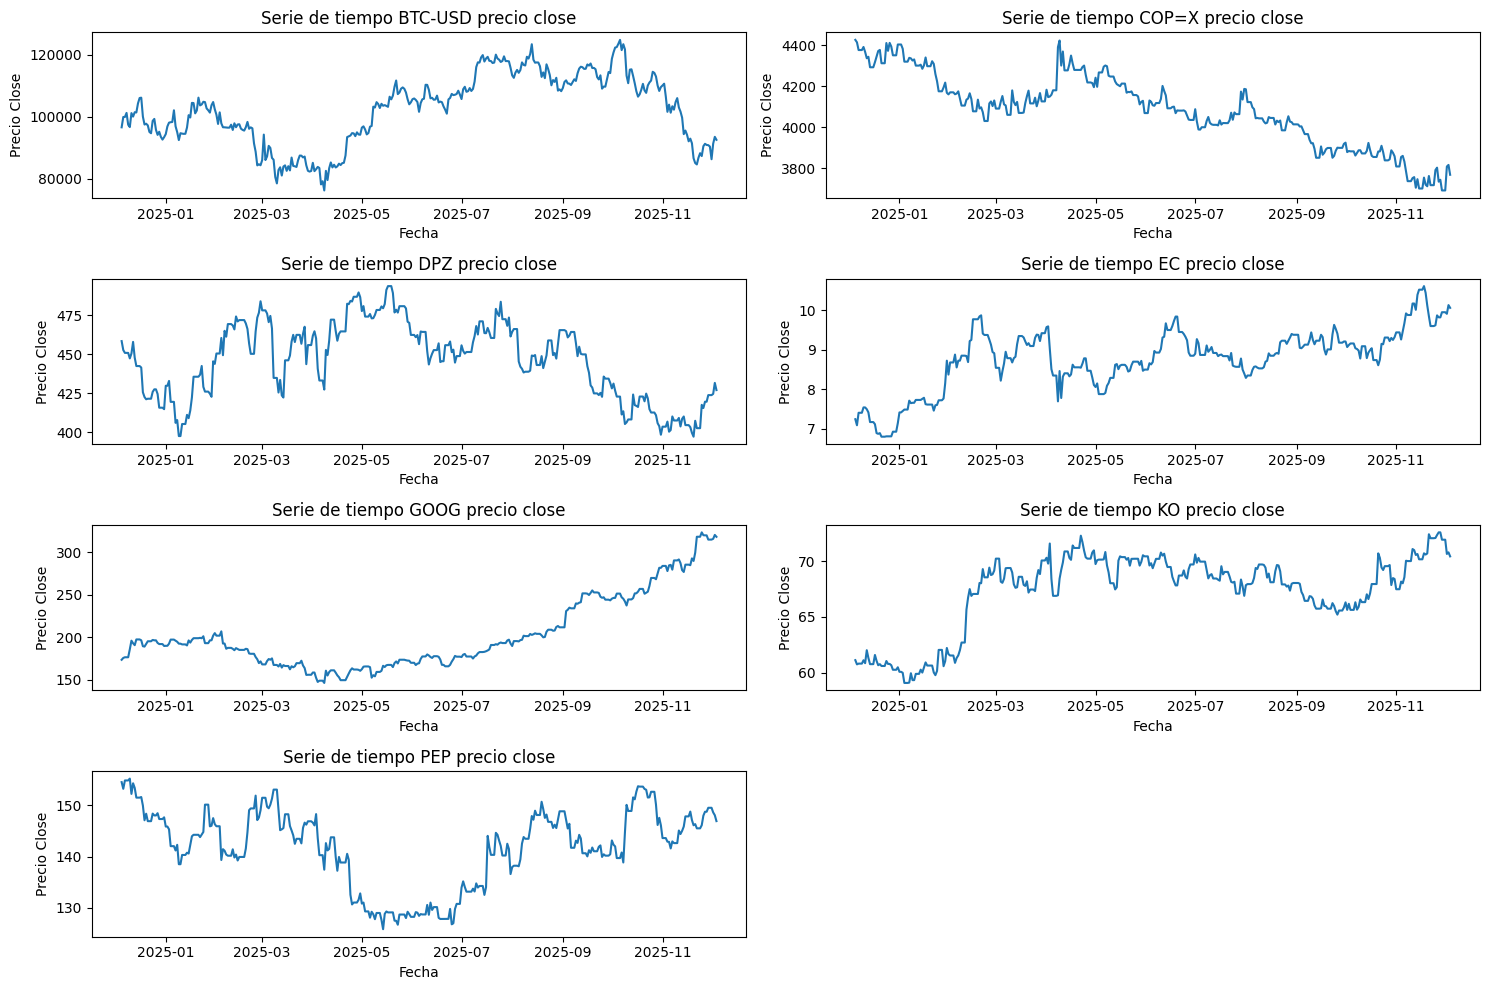

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.lineplot(x=close_data.index, y=close_data[column])
    plt.title(f'Serie de tiempo {column} precio close')
    plt.xlabel('Fecha')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

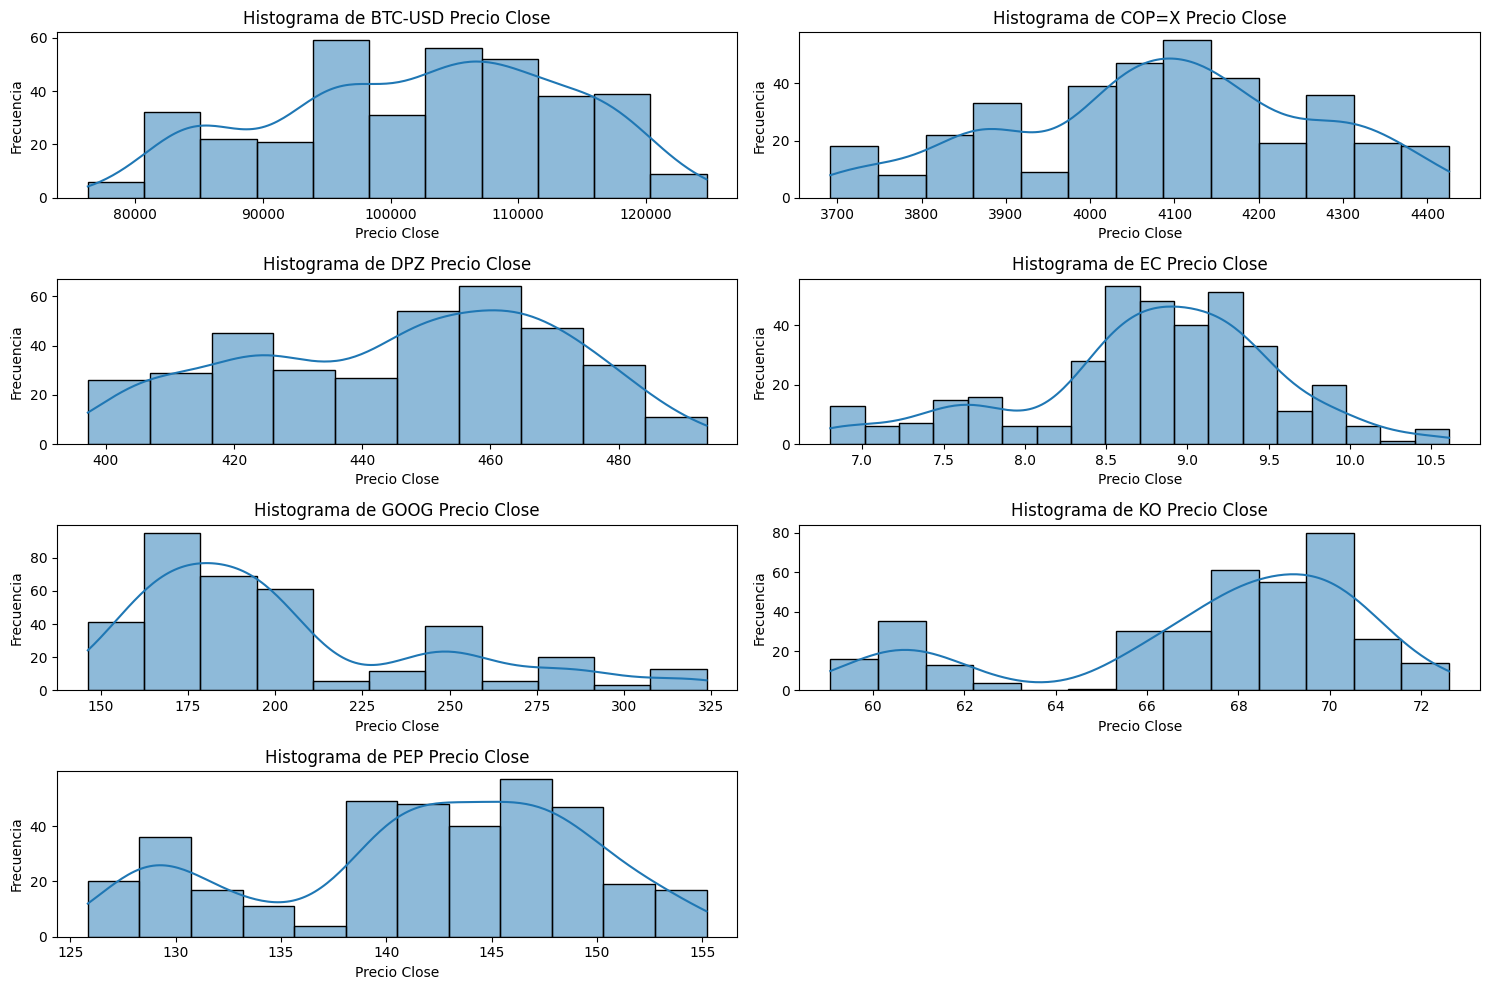

In [17]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.histplot(close_data[column], kde=True)
    plt.title(f'Histograma de {column} Precio Close')
    plt.xlabel('Precio Close')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

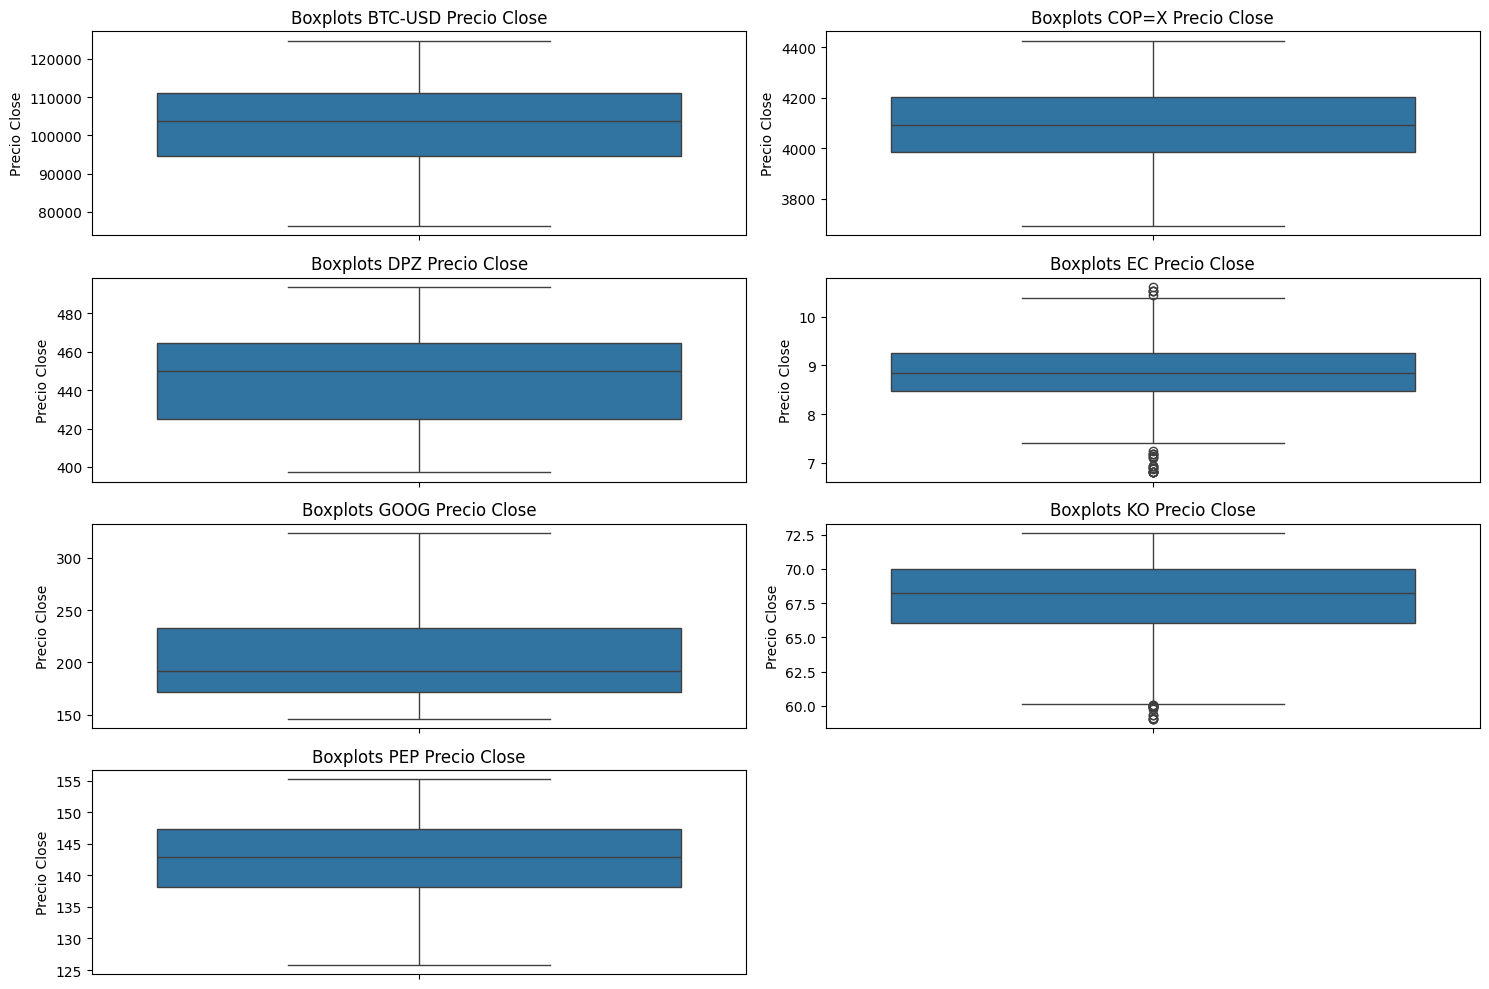

In [18]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.boxplot(y=close_data[column])
    plt.title(f'Boxplots {column} Precio Close')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

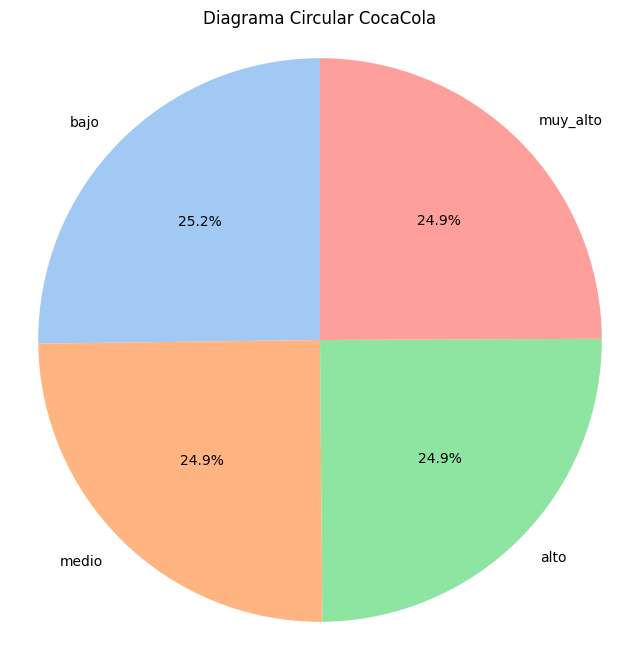

In [19]:
plt.figure(figsize=(8, 8))
volume_category_counts = data['Volume', 'catvolumeKO'].value_counts()
plt.pie(volume_category_counts, labels=volume_category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Diagrama Circular CocaCola')
plt.axis('equal')
plt.show()

In [20]:
## 7. Matriz de correllación de las variables

corr_k = data.corr(method="kendall", numeric_only=True)

corr_k

Price               Index     Close                                          \
Ticker                      BTC-USD     COP=X       DPZ        EC      GOOG   
Price   Ticker                                                                
Index            1.000000  0.327713 -0.725451 -0.201055  0.495523  0.463475   
Close   BTC-USD  0.327713  1.000000 -0.285206 -0.008140  0.056336  0.316772   
        COP=X   -0.725451 -0.285206  1.000000  0.260297 -0.600543 -0.508445   
        DPZ     -0.201055 -0.008140  0.260297  1.000000 -0.122647 -0.466535   
        EC       0.495523  0.056336 -0.600543 -0.122647  1.000000  0.259810   
        GOOG     0.463475  0.316772 -0.508445 -0.466535  0.259810  1.000000   
        KO       0.249405 -0.105613 -0.166322  0.216932  0.237515 -0.164663   
        PEP     -0.007914 -0.103461 -0.110537 -0.292432  0.026372  0.301106   
Volume  BTC-USD  0.218275  0.247840 -0.165921 -0.169943  0.019936  0.293949   
        COP=X         NaN       NaN       NaN       NaN       NaN       NaN   
        DPZ      0.026938 -0.003151 -0.082516 -0.019110  0.084885 -0.066902   
        EC      -0.202884 -0.254739  0.154452  0.033480 -0.065995 -0.168552   
        GOOG     0.126454 -0.004839 -0.093804  0.112724  0.105525 -0.069647   
        KO      -0.091244 -0.174846  0.036572 -0.002506  0.019993 -0.082389   
        PEP      0.014245  0.033991  0.018459  0.157674  0.036888 -0.161241   
BTC-COP          0.117868  0.748547 -0.033431  0.102713 -0.141451  0.163255   

Price                                  Volume                            \
Ticker                 KO       PEP   BTC-USD COP=X       DPZ        EC   
Price   Ticker                                                            
Index            0.249405 -0.007914  0.218275   NaN  0.026938 -0.202884   
Close   BTC-USD -0.105613 -0.103461  0.247840   NaN -0.003151 -0.254739   
        COP=X   -0.166322 -0.110537 -0.165921   NaN -0.082516  0.154452   
        DPZ      0.216932 -0.292432 -0.169943   NaN -0.019110  0.033480   
        EC       0.237515  0.026372  0.019936   NaN  0.084885 -0.065995   
        GOOG    -0.164663  0.301106  0.293949   NaN -0.066902 -0.168552   
        KO       1.000000 -0.127238 -0.042583   NaN -0.013741  0.017274   
        PEP     -0.127238  1.000000  0.151188   NaN  0.059463 -0.006386   
Volume  BTC-USD -0.042583  0.151188  1.000000   NaN -0.041469 -0.048644   
        COP=X         NaN       NaN       NaN   1.0       NaN       NaN   
        DPZ     -0.013741  0.059463 -0.041469   NaN  1.000000  0.110994   
        EC       0.017274 -0.006386 -0.048644   NaN  0.110994  1.000000   
        GOOG     0.168840 -0.097019  0.089282   NaN  0.079805  0.035034   
        KO      -0.044454  0.109823 -0.014697   NaN  0.189790  0.189760   
        PEP      0.081506 -0.218658 -0.001281   NaN  0.204365  0.137376   
BTC-COP         -0.165596 -0.150495  0.236098   NaN -0.043218 -0.227726   

Price                                           BTC-COP  
Ticker               GOOG        KO       PEP            
Price   Ticker                                           
Index            0.126454 -0.091244  0.014245  0.117868  
Close   BTC-USD -0.004839 -0.174846  0.033991  0.748547  
        COP=X   -0.093804  0.036572  0.018459 -0.033431  
        DPZ      0.112724 -0.002506  0.157674  0.102713  
        EC       0.105525  0.019993  0.036888 -0.141451  
        GOOG    -0.069647 -0.082389 -0.161241  0.163255  
        KO       0.168840 -0.044454  0.081506 -0.165596  
        PEP     -0.097019  0.109823 -0.218658 -0.150495  
Volume  BTC-USD  0.089282 -0.014697 -0.001281  0.236098  
        COP=X         NaN       NaN       NaN       NaN  
        DPZ      0.079805  0.189790  0.204365 -0.043218  
        EC       0.035034  0.189760  0.137376 -0.227726  
        GOOG     1.000000  0.245815  0.310622 -0.015451  
        KO       0.245815  1.000000  0.247808 -0.172344  
        PEP      0.310622  0.247808  1.000000  0.057084  
BTC-COP         -0.015451 -0

In [23]:
### 8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Calcular media móvil de 3 periodos
# Asigna la nueva columna usando un MultiIndex para que se integre correctamente
data[('Price', "KO")] = data['Close']["KO"].rolling(window=5).mean().shift(1).fillna(data['Close']["KO"].iloc[0:4].mean())

# Preparar datos (eliminar NaN de la nueva columna para el cálculo de métricas)
# Usa el nombre de la columna MultiIndex para subset
datos_ma5 = data.dropna(subset=[('Price', "KO")])

# Las 'predicciones' son ahora los valores de la media móvil
y_pred_ma = datos_ma5[('Price', "KO")].values

# Alinear los valores originales de 'KO' con la longitud de los datos de la media móvil
y_original_aligned = datos_ma5['Close']['KO'].values

# Parámetros y métricas
# En este enfoque de media móvil directa, no hay 'pendiente' ni 'intercepto' de un modelo de regresión
# Sin embargo, aún podemos calcular R2 y RMSE comparando la MA con los datos originales

r2 = r2_score(y_original_aligned, y_pred_ma)
rmse = np.sqrt(mean_squared_error(y_original_aligned, y_pred_ma))

print("="*50)
print("ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)")
print("="*50)
print(f"El pronóstico es directamente la Media Móvil de 5 períodos.")
print(f"\nMÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Observaciones: {len(y_original_aligned)}")

ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)
El pronóstico es directamente la Media Móvil de 5 períodos.

MÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):
R²: 0.9380
RMSE: 0.8727
Observaciones: 365


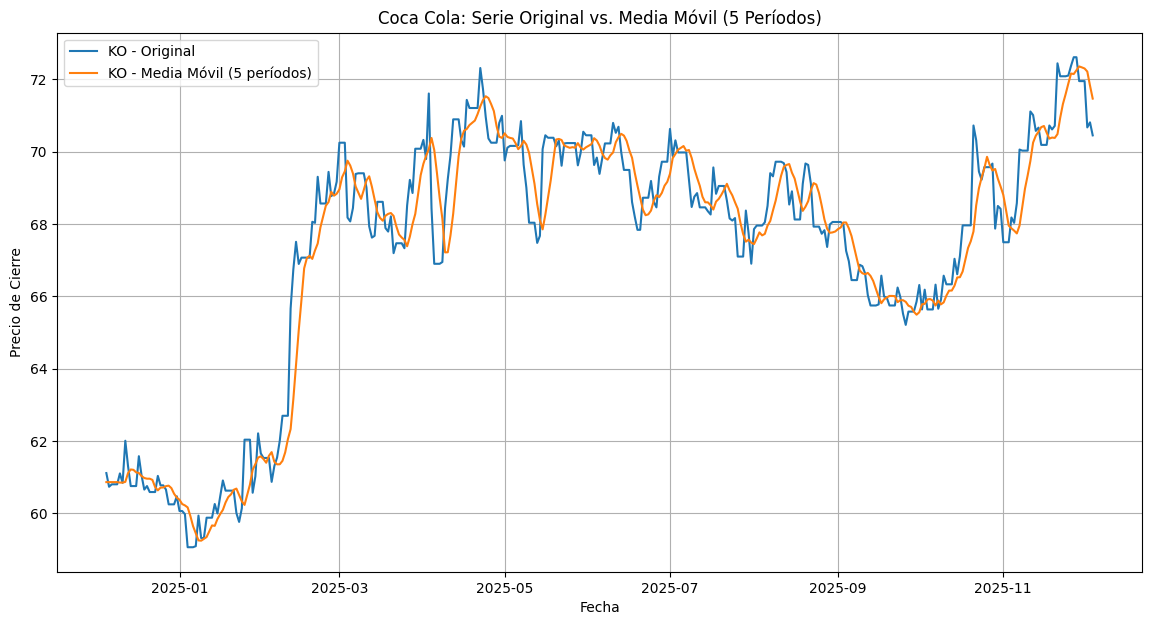

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=datos_ma5.index, y=datos_ma5['Close']['KO'], label='KO - Original')
sns.lineplot(x=datos_ma5.index, y=datos_ma5[('Price', 'KO')], label='KO - Media Móvil (5 períodos)')
plt.title('Coca Cola: Serie Original vs. Media Móvil (5 Períodos)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
data

Price      Index          Close                                      \
Ticker                  BTC-USD        COP=X         DPZ         EC   
Date                                                                  
2024-12-05     1   96593.570312  4425.750000  458.461304   7.245496   
2024-12-06     2   99920.710938  4413.669922  452.728210   7.092104   
2024-12-07     3   99923.335938  4376.152344  450.905823   7.407911   
2024-12-08     4  101236.015625  4376.152344  450.905823   7.407911   
2024-12-09     5   97432.718750  4376.152344  450.905823   7.407911   
...          ...            ...          ...         ...        ...   
2025-11-30   361   90394.312500  3691.856689  423.850006   9.950000   
2025-12-01   362   86321.570312  3691.856689  423.850006   9.950000   
2025-12-02   363   91350.203125  3808.399902  424.640015   9.910000   
2025-12-03   364   93527.804688  3816.250000  431.690002  10.130000   
2025-12-04   365   92567.500000  3768.149902  427.070007  10.060000   

Price                                                Volume                  \
Ticker            GOOG         KO         PEP       BTC-USD COP=X       DPZ   
Date                                                                          
2024-12-05  173.550430  61.116852  154.516800  1.492189e+11   0.0  466200.0   
2024-12-06  175.720917  60.738029  153.210815  9.453477e+10   0.0  387200.0   
2024-12-07  176.528305  60.806023  154.842056  4.417751e+10   0.0  504900.0   
2024-12-08  176.528305  60.806023  154.842056  4.412575e+10   0.0  504900.0   
2024-12-09  176.528305  60.806023  154.842056  1.106765e+11   0.0  504900.0   
...                ...        ...         ...           ...   ...       ...   
2025-11-30  315.119995  71.949997  149.509995  3.849790e+10   0.0  634700.0   
2025-12-01  315.119995  71.949997  149.509995  8.796289e+10   0.0  634700.0   
2025-12-02  316.019989  70.669998  148.610001  7.854680e+10   0.0  645000.0   
2025-12-03  320.619995  70.809998  148.059998  7.765020e+10   0.0  483900.0   
2025-12-04  318.390015  70.449997  146.910004  6.129335e+10   0.0  570800.0   

Price                                                                 \
Ticker             EC        GOOG          KO        PEP catvolumeKO   
Date                                                                   
2024-12-05  1803900.0  16145500.0  21040400.0  5229600.0    muy_alto   
2024-12-06  2430300.0  13319500.0  15581100.0  8359200.0        alto   
2024-12-07  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
2024-12-08  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
2024-12-09  3721300.0  19887800.0  22348300.0  8380400.0    muy_alto   
...               ...         ...         ...        ...         ...   
2025-11-30  1872800.0  28520600.0  14388100.0  7623300.0       medio   
2025-12-01  1872800.0  28520600.0  14388100.0  7623300.0       medio   
2025-12-02  1593100.0  24668200.0  19871300.0  6830300.0    muy_alto   
2025-12-03  1354500.0  32285100.0  17001700.0  5109200.0        alto   
2025-12-04  1104300.0  20803900.0  17704700.0  6802100.0        alto   

Price            BTC-COP      Price  
Ticker                           KO  
Date                                 
2024-12-05  4.274990e+08  60.866732  
2024-12-06  4.410170e+08  60.866732  
2024-12-07  4.372797e+08  60.866732  
2024-12-08  4.430242e+08  60.866732  
2024-12-09  4.263804e+08  60.866732  
...                  ...        ...  
2025-11-30  3.337228e+08  72.329047  
2025-12-01  3.186869e+08  72.298334  
2025-12-02  3.478981e+08  72.213998  
2025-12-03  3.569255e+08  71.825998  
2025-12-04  3.488082e+08  71.465997  

[365 rows x 18 columns]

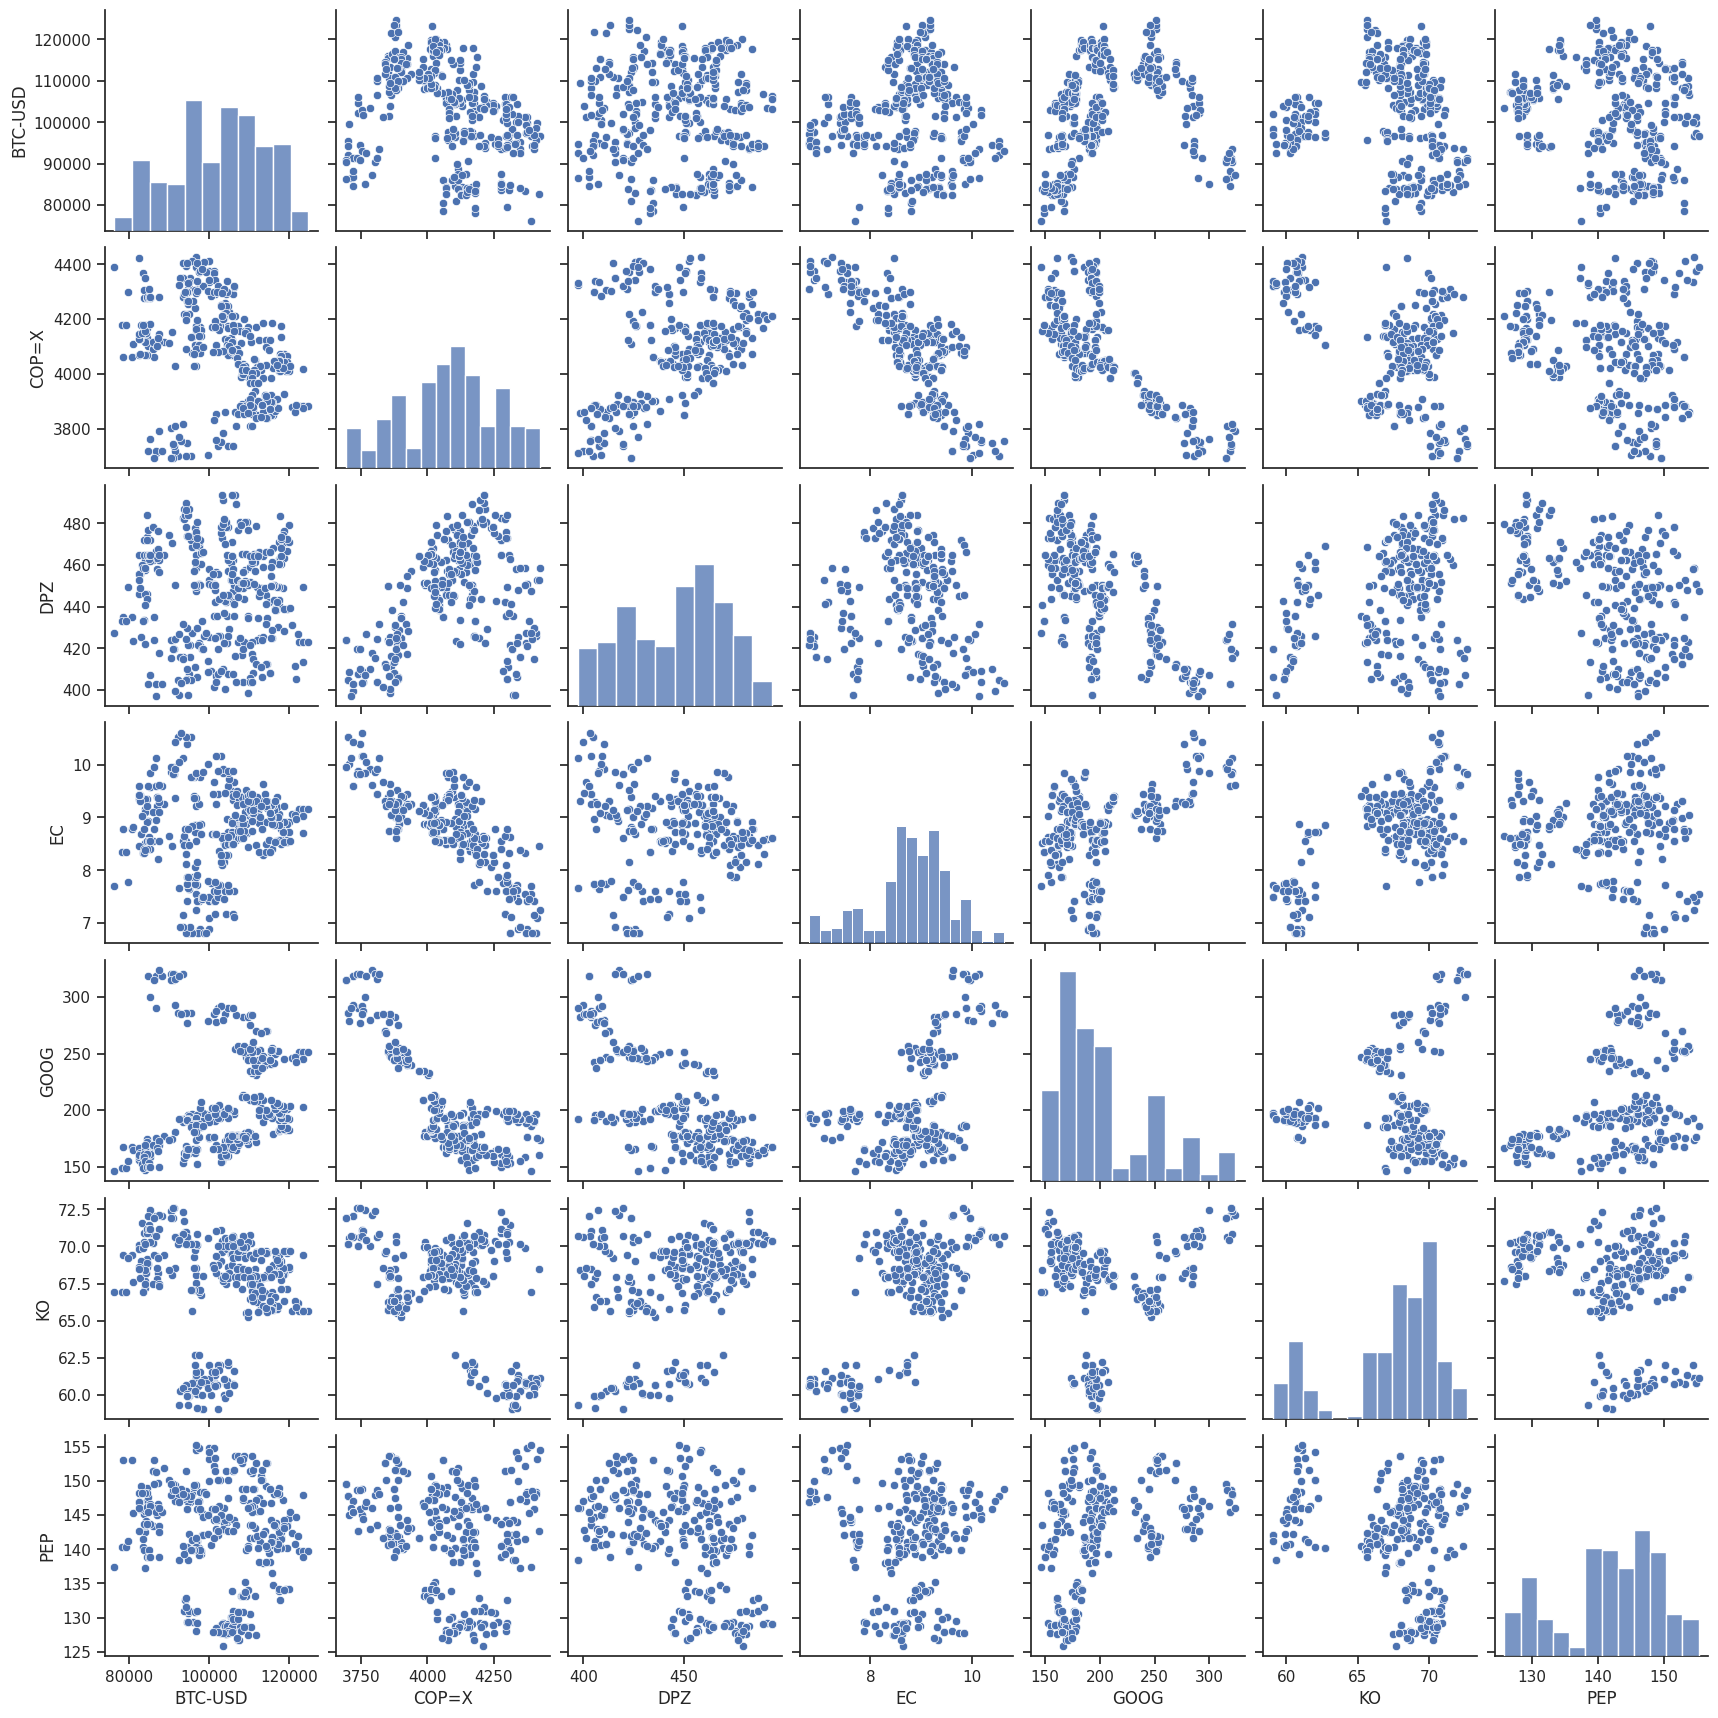

In [26]:
##9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

import seaborn as sns
sns.set(style="ticks")

sns.pairplot(data["Close"])


In [27]:
###10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

# Escogemos nuestra variable predictora como Coca Cola:
X=data["Close"]['KO'].values.reshape(-1,1)

# Escogemos nuestra variable objetivo  CIB:
y=data["Close"]['BTC-USD'].values.reshape(-1,1)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#seleccionamos los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)

#entrenamos el modelo
linear  = LinearRegression()
linear.fit(X_train,y_train)

LinearRegression()

In [29]:
y_pred = linear.predict(X_test)

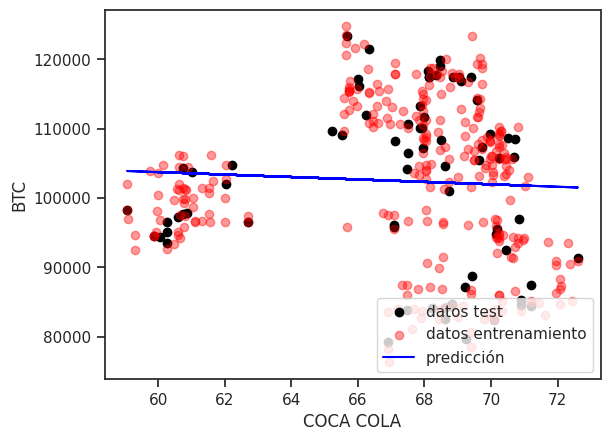

MAE:  10474.331969781291
MSE:  145169149.56447527
RMSE:  12048.616085031312
R2:  -0.002069578135656336


In [30]:
plt.scatter(X_test, y_test,  color='black',label=r'datos test')
plt.scatter(X_train, y_train,  color='red',alpha=0.4,label=r'datos entrenamiento')
plt.plot(X_test, y_pred, color='blue',label=r'predicción')
plt.legend(loc='lower right')
plt.xlabel(r'COCA COLA')
plt.ylabel(r'BTC')
plt.show()

print('MAE: ', metrics.mean_absolute_error(y_test, y_pred))
print('MSE: ', metrics.mean_squared_error(y_test, y_pred))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2: ', metrics.r2_score(y_test, y_pred))